# AUDIAX 


# Part I: Setup 


## 1. Dependency Verification


In [1]:
import importlib.util

_REQUIRED = [
    "torch", "torchaudio", "soundfile",
    "pandas", "sklearn", "matplotlib", "tabulate", "scipy", "numpy",
]
_missing = [m for m in _REQUIRED if importlib.util.find_spec(m) is None]
if _missing:
    raise RuntimeError(
        "Dependensi belum terpasang: " + ", ".join(_missing) + ". "
        "Jalankan `pip install -r requirements.txt` (root repo) sebelum "
        "menjalankan notebook ini."
    )
print("Semua dependensi terpasang (lihat requirements.txt di root repo).")


Semua dependensi terpasang (lihat requirements.txt di root repo).


In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("GPU tersedia:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("PERINGATAN: tidak ada GPU terdeteksi -- fine-tuning transformer di "
          "CPU sangat lambat. Kalau memakai Colab: Runtime > Change runtime type > GPU.")


PyTorch: 2.6.0+cu126
CUDA build: 12.6
GPU tersedia: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


## 2. Local BEATs Source


In [3]:
import sys
from pathlib import Path

BEATS_DIR = Path("../third_party/unilm/beats")
if not BEATS_DIR.exists():
    raise RuntimeError(
        f"{BEATS_DIR} tidak ditemukan. Notebook ini tidak lagi meng-clone BEATs "
        "secara otomatis -- vendor manual dulu (lihat README.md) sebelum lanjut."
    )

sys.path.insert(0, str(BEATS_DIR.resolve()))
print("BEATs source siap dari:", BEATS_DIR.resolve())


BEATs source siap dari: D:\AIC\audiax_model\third_party\unilm\beats


## 3. Pretrained BEATs Checkpoint


In [4]:
import os

BASE_CHECKPOINT = "../models/BEATs_iter3_plus_AS20K.pt"
MIN_VALID_SIZE_BYTES = 300_000_000


def _looks_valid(path: str) -> bool:
    return os.path.exists(path) and os.path.getsize(path) > MIN_VALID_SIZE_BYTES


if not _looks_valid(BASE_CHECKPOINT):
    raise RuntimeError(
        f"Checkpoint tidak ditemukan atau tidak valid: {BASE_CHECKPOINT}. "
        "Notebook ini tidak lagi mengunduh checkpoint secara otomatis -- taruh "
        "file .pt di folder models/ sebelum menjalankan sel ini."
    )

print(f"Checkpoint pretrained siap: {BASE_CHECKPOINT} "
      f"({os.path.getsize(BASE_CHECKPOINT)/1e6:.0f} MB)")


Checkpoint pretrained siap: ../models/BEATs_iter3_plus_AS20K.pt (361 MB)


## 4. Dataset 


In [5]:
DATASET_MODE = "local_multi"

assert DATASET_MODE in ("mimii", "local_multi", "custom"), f"DATASET_MODE tidak dikenal: {DATASET_MODE}"
print(f"DATASET_MODE = {DATASET_MODE}")

USES_HELDOUT_UNIT = DATASET_MODE in ("mimii", "local_multi")


DATASET_MODE = local_multi


In [7]:
if DATASET_MODE == "custom":
    from pathlib import Path
    CUSTOM_DATASET_ROOT = "../Dataset"

    assert os.path.isdir(CUSTOM_DATASET_ROOT), f"Folder dataset tidak ditemukan: {CUSTOM_DATASET_ROOT}"
    assert os.path.isdir(os.path.join(CUSTOM_DATASET_ROOT, "normal")), "Folder normal/ tidak ditemukan."
    assert os.path.isdir(os.path.join(CUSTOM_DATASET_ROOT, "abnormal")), "Folder abnormal/ tidak ditemukan."

    n_normal = len(list(Path(CUSTOM_DATASET_ROOT, "normal").glob("*.wav")))
    n_abnormal = len(list(Path(CUSTOM_DATASET_ROOT, "abnormal").glob("*.wav")))
    assert n_normal > 0, "Folder normal/ tidak berisi file .wav."
    assert n_abnormal > 0, "Folder abnormal/ tidak berisi file .wav."

    DATASET_ROOT = CUSTOM_DATASET_ROOT
    print(f"Dataset custom siap di: {CUSTOM_DATASET_ROOT} ({n_normal} normal, {n_abnormal} abnormal)")
    print("PERHATIAN: mode custom = SATU unit mesin. Held-out di notebook ini akan berbasis "
          "fraksi klip dari unit yang sama, BUKAN unit baru yang belum pernah dilihat -- "
          "ukuran generalisasinya lebih lemah daripada mode 'mimii'. Lihat Bagian 6.")
else:
    print("DATASET_MODE != 'custom' -- sel ini dilewati.")

DATASET_MODE != 'custom' -- sel ini dilewati.


### Loading Local Dataset 


In [8]:
if DATASET_MODE == "local_multi":
    from pathlib import Path
    LOCAL_MULTI_ROOT = "../Dataset"

    assert os.path.isdir(LOCAL_MULTI_ROOT), f"Folder dataset tidak ditemukan: {LOCAL_MULTI_ROOT}"
    found_ids = sorted(
        p.name for p in Path(LOCAL_MULTI_ROOT).iterdir() if p.is_dir() and p.name.startswith("id_")
    )
    assert found_ids, f"Tidak ada folder id_XX di {LOCAL_MULTI_ROOT}."

    counts = {}
    for mid in found_ids:
        for lab in ("normal", "abnormal"):
            d = Path(LOCAL_MULTI_ROOT, mid, lab)
            assert d.is_dir(), f"Folder {d} tidak ditemukan."
            n = len(list(d.glob("*.wav")))
            assert n > 0, f"Folder {d} tidak berisi file .wav."
            counts[(mid, lab)] = n

    DATASET_ROOT = LOCAL_MULTI_ROOT
    print(f"Dataset local_multi siap di: {LOCAL_MULTI_ROOT}. Machine IDs: {found_ids}")
    for (mid, lab), n in sorted(counts.items()):
        print(f"  {mid}/{lab}: {n} klip")
    print("Held-out akan berbasis UNIT PENUH (holdout_machine_id di Bagian 5 Config), "
          "sama seperti mode 'mimii' -- lihat Bagian 9.")
else:
    print("DATASET_MODE != 'local_multi' -- sel ini dilewati.")


Dataset local_multi siap di: ../Dataset. Machine IDs: ['id_00', 'id_02', 'id_04', 'id_06']
  id_00/abnormal: 407 klip
  id_00/normal: 1011 klip
  id_02/abnormal: 359 klip
  id_02/normal: 1016 klip
  id_04/abnormal: 348 klip
  id_04/normal: 1033 klip
  id_06/abnormal: 361 klip
  id_06/normal: 1015 klip
Held-out akan berbasis UNIT PENUH (holdout_machine_id di Bagian 5 Config), sama seperti mode 'mimii' -- lihat Bagian 9.


# Part II: Preprocessing & Data Prep 


## 5. Configuration


In [9]:
import warnings, copy
from dataclasses import dataclass, replace
from pathlib import Path
from typing import Optional, List, Dict, Tuple, Callable
import numpy as np
import pandas as pd
import scipy.signal as sig
import scipy.ndimage as ndi
import torch
import torch.nn as nn
import torch.nn.functional as F
import soundfile as sf
import torchaudio
from torch import Tensor
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")


@dataclass
class Config:
    sr: int = 16000
    min_duration_sec: float = 2.0
    max_clipping_ratio: float = 0.001
    min_snr_db: float = -10.0
    silence_rms: float = 1e-4
    bp_low: float = 50.0
    bp_high: float = 7500.0
    bp_order: int = 4
    notch_low: float = 300.0
    notch_high: float = 3400.0
    notch_order: int = 2
    window_sec: float = 2.0
    hop_sec: float = 1.0

    enable_denoise: bool = False
    denoise_harm_kernel: int = 31
    denoise_perc_kernel: int = 31
    denoise_mask_power: float = 2.0
    denoise_mask_floor: float = 0.1

    dataset_root: str = DATASET_ROOT
    snr_level: str = "-6_dB"
    machine_type: str = "fan"
    holdout_machine_id: str = "id_04"
    holdout_frac: float = 0.20
    max_clips_per_class_per_id: Optional[int] = None
    train_val_split_frac: float = 0.2

    n_unfrozen_layers: int = 2
    head_dropout: float = 0.3
    finetune_lr_backbone: float = 2e-5
    finetune_lr_head: float = 1e-3
    finetune_weight_decay: float = 1e-2
    finetune_batch_size: int = 16
    finetune_epochs_max: int = 15
    finetune_patience: int = 3
    finetune_warmup_ratio: float = 0.1

    aug_n_normal: int = 1
    aug_n_abnormal: int = 4
    aug_pitch_range: float = 2.0
    aug_gain_range_db: float = 6.0
    aug_noise_snr: Tuple[float, float] = (10.0, 30.0)

    knn_k: int = 5
    pca_variance_target: float = 0.95
    mahalanobis_shrinkage: float = 0.1
    z_warning: float = 3.0
    z_critical: float = 6.0
    min_calibration_windows: int = 20

    seed: int = 42

    def bp_clamped(self, fs: int) -> Tuple[float, float]:
        nyq = 0.5 * fs
        return max(1.0, min(self.bp_low, nyq * 0.98)), min(self.bp_high, nyq * 0.99)

    def notch_clamped(self, fs: int) -> Tuple[float, float]:
        nyq = 0.5 * fs
        return max(1.0, min(self.notch_low, nyq * 0.95)), min(self.notch_high, nyq * 0.98)


CFG = Config()
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
print(f"Config siap. dataset_mode={DATASET_MODE}, dataset_root={CFG.dataset_root}")


Config siap. dataset_mode=local_multi, dataset_root=../Dataset


## 6. Block A: Quality Gate, Conditioning, Windowing, Denoising


In [10]:
def estimate_snr(x: np.ndarray, fs: int) -> float:
    fl = max(int(0.05 * fs), 32)
    nf = max(len(x) // fl, 1)
    rms = np.sqrt(np.mean(x[:nf * fl].reshape(nf, fl) ** 2, axis=1) + 1e-12)
    return float(20 * np.log10((np.percentile(rms, 90) + 1e-12) / (np.percentile(rms, 10) + 1e-12)))


def quality_gate(x: np.ndarray, fs: int, cfg: Config) -> Tuple[bool, List[str], float]:
    reasons: List[str] = []
    if len(x) / fs < cfg.min_duration_sec:
        reasons.append("short")
    rms = float(np.sqrt(np.mean(x ** 2) + 1e-12))
    if rms < cfg.silence_rms:
        reasons.append("silent")
    cr = float(np.mean(np.abs(x) >= 0.999)) if len(x) else 1.0
    if cr > cfg.max_clipping_ratio:
        reasons.append("clipping")
    snr = estimate_snr(x, fs) if len(x) > 100 else -99.0
    if snr < cfg.min_snr_db:
        reasons.append("low_snr")
    return len(reasons) == 0, reasons, snr


def bandpass(x: np.ndarray, fs: int, cfg: Config) -> np.ndarray:
    lo, hi = cfg.bp_clamped(fs)
    nyq = 0.5 * fs
    b, a = sig.butter(cfg.bp_order, [lo / nyq, hi / nyq], btype="band")
    return sig.filtfilt(b, a, x).astype(np.float64)


def privacy_notch(x: np.ndarray, fs: int, cfg: Config) -> np.ndarray:
    lo, hi = cfg.notch_clamped(fs)
    nyq = 0.5 * fs
    b, a = sig.butter(cfg.notch_order, [lo / nyq, hi / nyq], btype="bandstop")
    return sig.filtfilt(b, a, x).astype(np.float64)


def peak_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x = x - np.mean(x)
    peak = np.max(np.abs(x))
    if peak < eps:
        return x
    return (x / peak).astype(np.float64)


def hpss_denoise(x: np.ndarray, fs: int, cfg: Config) -> np.ndarray:
    nperseg = 1024
    noverlap = nperseg - nperseg // 4
    if len(x) < nperseg:
        return x
    _, _, Zxx = sig.stft(x, fs=fs, nperseg=nperseg, noverlap=noverlap)
    mag = np.abs(Zxx)
    phase = np.angle(Zxx)
    harm = ndi.median_filter(mag, size=(1, cfg.denoise_harm_kernel), mode="reflect")
    perc = ndi.median_filter(mag, size=(cfg.denoise_perc_kernel, 1), mode="reflect")
    p = cfg.denoise_mask_power
    mask = (harm ** p) / (harm ** p + perc ** p + 1e-12)
    mask = cfg.denoise_mask_floor + (1.0 - cfg.denoise_mask_floor) * mask
    Zxx_denoised = mag * mask * np.exp(1j * phase)
    _, x_denoised = sig.istft(Zxx_denoised, fs=fs, nperseg=nperseg, noverlap=noverlap)
    if len(x_denoised) >= len(x):
        x_denoised = x_denoised[:len(x)]
    else:
        x_denoised = np.concatenate([x_denoised, np.zeros(len(x) - len(x_denoised))])
    return x_denoised.astype(np.float64)


def condition(x_raw: np.ndarray, fs: int, cfg: Config) -> np.ndarray:
    x_raw = np.asarray(x_raw)
    x = x_raw.astype(np.float64)
    if np.issubdtype(x_raw.dtype, np.integer):
        x = x / np.iinfo(x_raw.dtype).max
    x = bandpass(x, fs, cfg)
    x = privacy_notch(x, fs, cfg)
    if cfg.enable_denoise:
        x = hpss_denoise(x, fs, cfg)
    return peak_normalize(x)


def make_windows(x: np.ndarray, fs: int, cfg: Config) -> List[np.ndarray]:
    win = int(cfg.window_sec * fs)
    hop = int(cfg.hop_sec * fs)
    if win <= 0 or len(x) < win:
        return []
    windows: List[np.ndarray] = []
    start = 0
    while start + win <= len(x):
        w = x[start:start + win]
        ok, _, _ = quality_gate(w, fs, cfg)
        if ok:
            windows.append(w)
        start += hop
    return windows


def load_audio(path: str, cfg: Config) -> np.ndarray:
    audio, srate = sf.read(path, dtype="float32", always_2d=True)
    waveform = torch.from_numpy(audio.T)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if srate != cfg.sr:
        waveform = torchaudio.functional.resample(waveform, srate, cfg.sr)
    return waveform.squeeze(0).numpy().astype(np.float64)


print("Blok A ready.")

Blok A ready.



## 7. Augmentation

In [11]:
def aug_pitch(x: np.ndarray, fs: int, semi: float) -> np.ndarray:
    ratio = 2.0 ** (semi / 12.0)
    new_len = int(len(x) / ratio)
    if new_len < 10:
        return x.copy()
    xs = sig.resample(x, new_len)
    if len(xs) >= len(x):
        return xs[:len(x)]
    out = np.zeros_like(x)
    out[:len(xs)] = xs
    return out


def aug_gain(x: np.ndarray, db: float) -> np.ndarray:
    return x * 10.0 ** (db / 20.0)


def aug_noise(x: np.ndarray, snr_db: float, rng: np.random.RandomState) -> np.ndarray:
    sp = np.mean(x ** 2) + 1e-12
    npw = sp / 10.0 ** (snr_db / 10.0)
    return x + rng.normal(0, np.sqrt(npw), len(x))


def augment(x: np.ndarray, fs: int, cfg: Config, rng: np.random.RandomState, n: int) -> List[np.ndarray]:
    variants: List[np.ndarray] = []
    for _ in range(n):
        xa = x.copy()
        xa = aug_pitch(xa, fs, rng.uniform(-cfg.aug_pitch_range, cfg.aug_pitch_range))
        xa = aug_gain(xa, rng.uniform(-cfg.aug_gain_range_db, cfg.aug_gain_range_db))
        xa = aug_noise(xa, rng.uniform(*cfg.aug_noise_snr), rng)
        xa = peak_normalize(xa)
        variants.append(xa)
    return variants

print("Augmentasi ready.")

Augmentasi ready.


## 8. Manifest 


In [12]:
def discover_ids(cfg: Config) -> List[str]:
    if DATASET_MODE == "custom":
        return ["id_00"]
    if DATASET_MODE == "local_multi":
        d = Path(cfg.dataset_root)
        return sorted([p.name for p in d.iterdir() if p.is_dir() and p.name.startswith("id_")]) if d.exists() else []
    d = Path(cfg.dataset_root) / f"{cfg.snr_level}_{cfg.machine_type}" / cfg.machine_type
    return sorted([p.name for p in d.iterdir() if p.is_dir() and p.name.startswith("id_")]) if d.exists() else []


def list_wavs(cfg: Config, mid: str, label: str) -> List[str]:
    if DATASET_MODE == "custom":
        d = Path(cfg.dataset_root) / label
    elif DATASET_MODE == "local_multi":
        d = Path(cfg.dataset_root) / mid / label
    else:
        d = Path(cfg.dataset_root) / f"{cfg.snr_level}_{cfg.machine_type}" / cfg.machine_type / mid / label
    return sorted(str(p) for p in d.glob("*.wav")) if d.exists() else []


def build_manifest(cfg: Config) -> pd.DataFrame:
    rows = []
    for mid in discover_ids(cfg):
        for lab in ("normal", "abnormal"):
            for p in list_wavs(cfg, mid, lab):
                rows.append({"path": p, "model_id": mid, "label": lab})
    return pd.DataFrame(rows, columns=["path", "model_id", "label"])


MF = build_manifest(CFG)
print(f"Mode: {DATASET_MODE}. Manifest: {len(MF)} file. Machine IDs: {discover_ids(CFG)}")
assert len(MF) > 0, (
    "Manifest kosong. Mode 'mimii': cek CFG.dataset_root & struktur "
    "<root>/-6_dB_fan/fan/id_XX/{normal,abnormal}/*.wav. "
    "Mode 'local_multi': cek CFG.dataset_root & struktur <root>/id_XX/{normal,abnormal}/*.wav. "
    "Mode 'custom': cek CFG.dataset_root & struktur <root>/{normal,abnormal}/*.wav."
)
print(MF.groupby(["model_id", "label"]).size())


Mode: local_multi. Manifest: 5550 file. Machine IDs: ['id_00', 'id_02', 'id_04', 'id_06']
model_id  label   
id_00     abnormal     407
          normal      1011
id_02     abnormal     359
          normal      1016
id_04     abnormal     348
          normal      1033
id_06     abnormal     361
          normal      1015
dtype: int64


## 9. Dataset Splitting


In [13]:
def subsample(df: pd.DataFrame, cap: Optional[int], seed: int) -> pd.DataFrame:
    parts = []
    for mid, g_mid in df.groupby("model_id"):
        label_counts = g_mid.groupby("label").size()
        local_min = int(label_counts.min())
        n = local_min if cap is None else min(local_min, cap)
        print(f"  subsample[{mid}]: label counts {dict(label_counts)} -> n={n} per label")
        for _lab, g in g_mid.groupby("label"):
            parts.append(g.sample(n=min(len(g), n), random_state=seed))
    return pd.concat(parts, ignore_index=True) if parts else df.iloc[0:0]


if USES_HELDOUT_UNIT:
    assert CFG.holdout_machine_id in MF.model_id.unique(), (
        f"holdout_machine_id={CFG.holdout_machine_id} tidak ada di manifest. "
        f"ID tersedia: {discover_ids(CFG)}"
    )
    seen = MF[MF.model_id != CFG.holdout_machine_id].copy()
    heldout = MF[MF.model_id == CFG.holdout_machine_id].copy()

    seen_sub = subsample(seen, CFG.max_clips_per_class_per_id, CFG.seed)
    heldout_sub = subsample(heldout, CFG.max_clips_per_class_per_id, CFG.seed)

    train_df, val_df = train_test_split(
        seen_sub, test_size=CFG.train_val_split_frac,
        stratify=seen_sub["label"], random_state=CFG.seed,
    )
    HELDOUT_LABEL = f"unit baru {CFG.holdout_machine_id} (belum pernah dilihat)"

else:
    all_sub = subsample(MF, CFG.max_clips_per_class_per_id, CFG.seed)
    trainval_df, heldout_sub = train_test_split(
        all_sub, test_size=CFG.holdout_frac,
        stratify=all_sub["label"], random_state=CFG.seed,
    )
    train_df, val_df = train_test_split(
        trainval_df, test_size=CFG.train_val_split_frac,
        stratify=trainval_df["label"], random_state=CFG.seed,
    )
    HELDOUT_LABEL = f"fraksi klip ({CFG.holdout_frac:.0%}) dari unit yang SAMA -- BUKAN unit baru"

print(f"Held-out mengukur: {HELDOUT_LABEL}")
print(f"Train clips: {len(train_df)} | Val clips: {len(val_df)} | Held-out clips: {len(heldout_sub)}")
print("Train label dist:\n", train_df.label.value_counts())
print("Val label dist:\n", val_df.label.value_counts())
print("Held-out label dist:\n", heldout_sub.label.value_counts())

assert set(train_df.path) & set(val_df.path) == set(), "LEAK: train/val overlap!"
assert set(train_df.path) & set(heldout_sub.path) == set(), "LEAK: train/heldout overlap!"
assert set(val_df.path) & set(heldout_sub.path) == set(), "LEAK: val/heldout overlap!"
print("Tidak ada kebocoran data (train/val/held-out disjoint by clip).")

if USES_HELDOUT_UNIT:
    SEEN_MACHINE_IDS = sorted(seen_sub.model_id.unique())
else:
    SEEN_MACHINE_IDS = sorted(train_df.model_id.unique())
assert len(SEEN_MACHINE_IDS) >= 2, (
    f"MAC butuh >=2 machine_id untuk diklasifikasikan, cuma ada {SEEN_MACHINE_IDS}. "
    "Mode 'custom' (satu unit) tidak mendukung MAC -- lihat CLAUDE.md keputusan desain #1."
)
MID_TO_IDX = {mid: i for i, mid in enumerate(SEEN_MACHINE_IDS)}
print(f"MAC classes (machine_id yang dilihat saat training): {SEEN_MACHINE_IDS}")


  subsample[id_00]: label counts {'abnormal': np.int64(407), 'normal': np.int64(1011)} -> n=407 per label
  subsample[id_02]: label counts {'abnormal': np.int64(359), 'normal': np.int64(1016)} -> n=359 per label
  subsample[id_06]: label counts {'abnormal': np.int64(361), 'normal': np.int64(1015)} -> n=361 per label
  subsample[id_04]: label counts {'abnormal': np.int64(348), 'normal': np.int64(1033)} -> n=348 per label
Held-out mengukur: unit baru id_04 (belum pernah dilihat)
Train clips: 1803 | Val clips: 451 | Held-out clips: 696
Train label dist:
 label
normal      902
abnormal    901
Name: count, dtype: int64
Val label dist:
 label
abnormal    226
normal      225
Name: count, dtype: int64
Held-out label dist:
 label
abnormal    348
normal      348
Name: count, dtype: int64
Tidak ada kebocoran data (train/val/held-out disjoint by clip).
MAC classes (machine_id yang dilihat saat training): ['id_00', 'id_02', 'id_06']


## 10. Windowing for Training + Augmentation of Normal Clips for MAC


In [14]:
TRAIN_CFG = replace(CFG, hop_sec=CFG.window_sec)


def build_window_dataset(
    df: pd.DataFrame,
    cfg: Config,
    train_cfg: Config,
    with_aug: bool = False,
    aug_rng: Optional[np.random.RandomState] = None,
) -> Tuple[List[np.ndarray], np.ndarray, np.ndarray, List[str]]:
    X: List[np.ndarray] = []
    y: List[int] = []
    mids: List[int] = []
    groups: List[str] = []
    for _, row in df.iterrows():
        raw = load_audio(row["path"], cfg)
        xc = condition(raw, cfg.sr, cfg)
        label = 1 if row["label"] == "abnormal" else 0
        mid_idx = MID_TO_IDX.get(row["model_id"], -1)

        clips = [xc]
        if with_aug:
            assert aug_rng is not None, "aug_rng wajib diisi kalau with_aug=True"
            n_aug = cfg.aug_n_abnormal if label == 1 else cfg.aug_n_normal
            clips.extend(augment(xc, cfg.sr, cfg, aug_rng, n_aug))

        for clip in clips:
            for w in make_windows(clip, cfg.sr, train_cfg):
                X.append(w.astype(np.float32))
                y.append(label)
                mids.append(mid_idx)
                groups.append(row["path"])
    return X, np.array(y, dtype=np.float32), np.array(mids, dtype=np.int64), groups


AUG_RNG = np.random.RandomState(CFG.seed + 1)

train_df_mac = train_df[train_df.label == "normal"]
val_df_mac = val_df[val_df.label == "normal"]
assert len(train_df_mac) > 0 and len(val_df_mac) > 0, (
    "Tidak ada klip normal di train/val -- MAC hanya boleh dilatih dari data normal "
    "(label abnormal cuma dipakai saat evaluasi, tidak pernah saat training adapter)."
)

print("Membangun window set training (MAC -- hanya klip normal)...")
X_train, y_train, mid_train, g_train = build_window_dataset(
    train_df_mac, CFG, TRAIN_CFG, with_aug=True, aug_rng=AUG_RNG
)
print(f"  train windows: {len(X_train)}  (per kelas machine_id: "
      f"{dict(zip(*np.unique(mid_train, return_counts=True)))})")

print("Membangun window set validasi (MAC -- hanya klip normal)...")
X_val, y_val, mid_val, g_val = build_window_dataset(val_df_mac, CFG, TRAIN_CFG, with_aug=False)
print(f"  val windows: {len(X_val)}  (per kelas machine_id: "
      f"{dict(zip(*np.unique(mid_val, return_counts=True)))})")

print("Membangun window set held-out (normal+abnormal, untuk AUC generalisasi Bagian 16)...")
X_heldout, y_heldout, mid_heldout, g_heldout = build_window_dataset(heldout_sub, CFG, TRAIN_CFG, with_aug=False)
print(f"  held-out windows: {len(X_heldout)}  (pos={int(y_heldout.sum())}, neg={int((1-y_heldout).sum())})")

assert len(X_train) > 0 and len(X_val) > 0 and len(X_heldout) > 0, \
    "Salah satu split menghasilkan 0 window -- cek Quality Gate / durasi klip."


Membangun window set training (MAC -- hanya klip normal)...
  train windows: 9020  (per kelas machine_id: {np.int64(0): np.int64(3310), np.int64(1): np.int64(2860), np.int64(2): np.int64(2850)})
Membangun window set validasi (MAC -- hanya klip normal)...
  val windows: 1125  (per kelas machine_id: {np.int64(0): np.int64(380), np.int64(1): np.int64(365), np.int64(2): np.int64(380)})
Membangun window set held-out (normal+abnormal, untuk AUC generalisasi Bagian 16)...
  held-out windows: 3480  (pos=1740, neg=1740)


## 11. Dataset & Balanced Sampler


In [15]:
class WindowDataset(Dataset):
    def __init__(self, X: List[np.ndarray], y: np.ndarray, mid: np.ndarray) -> None:
        self.X = X
        self.y = y
        self.mid = mid

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> Tuple[Tensor, Tensor, Tensor]:
        return (
            torch.from_numpy(self.X[idx]),
            torch.tensor(self.y[idx], dtype=torch.float32),
            torch.tensor(self.mid[idx], dtype=torch.long),
        )


train_ds = WindowDataset(X_train, y_train, mid_train)
val_ds = WindowDataset(X_val, y_val, mid_val)
heldout_ds = WindowDataset(X_heldout, y_heldout, mid_heldout)

n_classes = len(SEEN_MACHINE_IDS)
class_count = np.array([(mid_train == c).sum() for c in range(n_classes)], dtype=np.float64)
class_weight = 1.0 / np.maximum(class_count, 1)
sample_weight = np.array([class_weight[c] for c in mid_train])
train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.from_numpy(sample_weight).double(),
    num_samples=len(mid_train),
    replacement=True,
)

train_loader = DataLoader(train_ds, batch_size=CFG.finetune_batch_size, sampler=train_sampler)
val_loader = DataLoader(val_ds, batch_size=CFG.finetune_batch_size, shuffle=False)
heldout_loader = DataLoader(heldout_ds, batch_size=CFG.finetune_batch_size, shuffle=False)

print(f"DataLoader siap. {n_classes} kelas machine_id (MAC): {SEEN_MACHINE_IDS}")


DataLoader siap. 3 kelas machine_id (MAC): ['id_00', 'id_02', 'id_06']


# Part III: Training & Model 


## 12. Load Pretrained BEATs + MAC


In [16]:
from BEATs import BEATs, BEATsConfig

device: str = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cpu":
    print("PERINGATAN: tidak ada GPU terdeteksi. Fine-tuning transformer di CPU sangat "
          "lambat -- disarankan Runtime > Change runtime type > GPU sebelum lanjut.")

checkpoint = torch.load(BASE_CHECKPOINT, map_location=device, weights_only=False)
beats_cfg = BEATsConfig(checkpoint['cfg'])
beats_model = BEATs(beats_cfg)
beats_model.load_state_dict(checkpoint['model'])
beats_model = beats_model.to(device)
print(f"BEATs pretrained dimuat. encoder_layers={beats_cfg.encoder_layers}, "
      f"encoder_embed_dim={beats_cfg.encoder_embed_dim}")


class BEATsClassifier(nn.Module):

    def __init__(self, backbone: BEATs, n_unfrozen_layers: int, n_classes: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.backbone = backbone
        for p in self.backbone.parameters():
            p.requires_grad = False
        total_layers = len(self.backbone.encoder.layers)
        n_unfrozen = min(n_unfrozen_layers, total_layers)
        for layer in self.backbone.encoder.layers[total_layers - n_unfrozen:]:
            for p in layer.parameters():
                p.requires_grad = True
        for p in self.backbone.layer_norm.parameters():
            p.requires_grad = True
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(self.backbone.cfg.encoder_embed_dim, n_classes)

    def forward(self, wav: Tensor) -> Tensor:
        padding_mask = torch.zeros(wav.shape, dtype=torch.bool, device=wav.device)
        feats, _ = self.backbone.extract_features(wav, padding_mask=padding_mask)
        pooled = feats.mean(dim=1)
        pooled = self.dropout(pooled)
        return self.head(pooled)

    def embed(self, wav: Tensor) -> Tensor:
        with torch.inference_mode():
            padding_mask = torch.zeros(wav.shape, dtype=torch.bool, device=wav.device)
            feats, _ = self.backbone.extract_features(wav, padding_mask=padding_mask)
            emb = feats.mean(dim=1)
            return emb / (emb.norm(dim=-1, keepdim=True) + 1e-12)


model = BEATsClassifier(beats_model, CFG.n_unfrozen_layers, n_classes, CFG.head_dropout).to(device)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {n_trainable:,} / {n_total:,} ({100*n_trainable/n_total:.1f}%) "
      f"-- {CFG.n_unfrozen_layers} dari {len(beats_model.encoder.layers)} layer encoder dibuka.")
assert 0 < n_trainable < n_total, "Freeze/unfreeze logic salah (semua layer beku atau semua terbuka)!"


device: cuda
BEATs pretrained dimuat. encoder_layers=12, encoder_embed_dim=768
Trainable params: 14,183,979 / 90,314,099 (15.7%) -- 2 dari 12 layer encoder dibuka.


## 13. Cross-Entropy Loss Function (MAC)


In [17]:
criterion = nn.CrossEntropyLoss()
print(f"Loss function: CrossEntropyLoss -- {n_classes} kelas machine_id "
      f"(Machine Attribute Classification, label abnormal TIDAK dipakai saat training).")


Loss function: CrossEntropyLoss -- 3 kelas machine_id (Machine Attribute Classification, label abnormal TIDAK dipakai saat training).


## 14. Learning Rate Scheduler: Linear Warmup + Cosine Annealing


In [18]:
def build_warmup_cosine_scheduler(
    optimizer: torch.optim.Optimizer,
    num_warmup_steps: int,
    num_training_steps: int,
    min_lr_ratio: float = 0.0,
) -> torch.optim.lr_scheduler.LambdaLR:
    def lr_lambda(current_step: int) -> float:
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(
            max(1, num_training_steps - num_warmup_steps)
        )
        progress = min(progress, 1.0)
        cosine = 0.5 * (1.0 + np.cos(np.pi * progress))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cosine

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


backbone_params = [p for n_, p in model.backbone.named_parameters() if p.requires_grad]
head_params = list(model.head.parameters())

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": CFG.finetune_lr_backbone},
    {"params": head_params, "lr": CFG.finetune_lr_head},
], weight_decay=CFG.finetune_weight_decay)

steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * CFG.finetune_epochs_max
warmup_steps = max(1, int(CFG.finetune_warmup_ratio * total_steps))
lr_scheduler = build_warmup_cosine_scheduler(optimizer, warmup_steps, total_steps, min_lr_ratio=0.05)

print(f"Scheduler siap: warmup {warmup_steps} step -> cosine annealing hingga {total_steps} step total.")

Scheduler siap: warmup 846 step -> cosine annealing hingga 8460 step total.


## 15. Training Loop 


In [19]:
@dataclass
class EpochMetrics:
    loss: float
    accuracy: float

    def __str__(self) -> str:
        return f"loss={self.loss:.4f} acc={self.accuracy:.3f}"


def run_epoch(
    loader: DataLoader,
    train_mode: bool,
    scheduler: Optional[torch.optim.lr_scheduler.LambdaLR] = None,
) -> EpochMetrics:
    model.train(train_mode)
    total_loss = 0.0
    n_correct = 0
    n_total = 0

    grad_context = torch.enable_grad() if train_mode else torch.inference_mode()
    with grad_context:
        for wav, _label_bin, mid in loader:
            wav, mid = wav.to(device), mid.to(device)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
            logits = model(wav)
            loss = criterion(logits, mid)
            if train_mode:
                loss.backward()
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()
            total_loss += loss.item() * len(mid)
            preds = logits.argmax(dim=-1)
            n_correct += (preds == mid).sum().item()
            n_total += len(mid)

    avg_loss = total_loss / len(loader.dataset)
    accuracy = n_correct / max(n_total, 1)
    return EpochMetrics(loss=avg_loss, accuracy=accuracy)


_check_mids: List[int] = []
for _, _label_bin, mid in train_loader:
    _check_mids.extend(mid.numpy().tolist())
    if len(_check_mids) >= 200:
        break
_props = np.bincount(_check_mids, minlength=n_classes) / len(_check_mids)
print(f"Proporsi kelas machine_id di batch ter-sampling (target ~{1/n_classes:.3f} tiap kelas): {_props}")
assert _props.min() > 0.5 / n_classes, f"Sampler tidak menyeimbangkan kelas dengan baik: {_props}"

history: Dict[str, List[float]] = {
    "train_loss": [], "train_acc": [],
    "val_loss": [], "val_acc": [],
    "lr_backbone": [], "lr_head": [],
}
best_val_acc: float = -1.0
best_state: Optional[Dict[str, Tensor]] = None
patience_ctr: int = 0

print("\nMulai training...")
for epoch in range(CFG.finetune_epochs_max):
    tr = run_epoch(train_loader, train_mode=True, scheduler=lr_scheduler)
    va = run_epoch(val_loader, train_mode=False)

    history["train_loss"].append(tr.loss); history["train_acc"].append(tr.accuracy)
    history["val_loss"].append(va.loss); history["val_acc"].append(va.accuracy)
    history["lr_backbone"].append(optimizer.param_groups[0]["lr"])
    history["lr_head"].append(optimizer.param_groups[1]["lr"])

    print(f"  epoch {epoch+1:02d} [train] {tr}")
    print(f"              [val]   {va}")

    if va.accuracy > best_val_acc:
        best_val_acc = va.accuracy
        best_state = copy.deepcopy(model.backbone.state_dict())
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= CFG.finetune_patience:
            print(f"  Early stopping (val_acc tidak membaik {CFG.finetune_patience} epoch berturut-turut).")
            break

    if device == "cuda":
        torch.cuda.empty_cache()

assert best_state is not None, "Tidak ada checkpoint terbaik tersimpan!"
model.backbone.load_state_dict(best_state)
print(f"\nBest val accuracy (proxy task MAC): {best_val_acc:.4f} -- backbone dikembalikan ke state terbaik.")


Proporsi kelas machine_id di batch ter-sampling (target ~0.333 tiap kelas): [0.33173077 0.26442308 0.40384615]

Mulai training...
  epoch 01 [train] loss=0.6869 acc=0.724
              [val]   loss=0.1320 acc=0.950
  epoch 02 [train] loss=0.1525 acc=0.950
              [val]   loss=0.0507 acc=0.983
  epoch 03 [train] loss=0.0833 acc=0.973
              [val]   loss=0.0439 acc=0.987
  epoch 04 [train] loss=0.0539 acc=0.982
              [val]   loss=0.0332 acc=0.988
  epoch 05 [train] loss=0.0485 acc=0.985
              [val]   loss=0.0460 acc=0.989
  epoch 06 [train] loss=0.0425 acc=0.986
              [val]   loss=0.0351 acc=0.991
  epoch 07 [train] loss=0.0395 acc=0.987
              [val]   loss=0.0317 acc=0.990
  epoch 08 [train] loss=0.0404 acc=0.986
              [val]   loss=0.0236 acc=0.994
  epoch 09 [train] loss=0.0276 acc=0.991
              [val]   loss=0.0503 acc=0.989
  epoch 10 [train] loss=0.0220 acc=0.994
              [val]   loss=0.0487 acc=0.989
  epoch 11 [train] l

## 16. Generalization Evaluation on Held-out Set


In [20]:
def compute_normal_centroid(embed_fn: Callable[[Tensor], Tensor], loader: DataLoader) -> Tensor:
    embs: List[Tensor] = []
    with torch.inference_mode():
        for wav, label, _mid in loader:
            mask = label.numpy() == 0
            if mask.sum() == 0:
                continue
            e = embed_fn(wav[torch.from_numpy(mask)].to(device))
            embs.append(e)
    return torch.cat(embs, dim=0).mean(dim=0)


def compute_cosine_distances(
    embed_fn: Callable[[Tensor], Tensor], loader: DataLoader, centroid: Tensor
) -> Tuple[List[float], List[float]]:
    dists: List[float] = []
    labels: List[float] = []
    with torch.inference_mode():
        for wav, label, _mid in loader:
            e = embed_fn(wav.to(device))
            d = 1 - F.cosine_similarity(e, centroid.unsqueeze(0).expand(e.shape[0], -1))
            dists.extend(d.cpu().numpy().tolist())
            labels.extend(label.numpy().tolist())
    return dists, labels


model.eval()
centroid = compute_normal_centroid(model.embed, train_loader)
dists_ft, labels_ho = compute_cosine_distances(model.embed, heldout_loader, centroid)
auc_embedding_finetuned = roc_auc_score(labels_ho, dists_ft)
print(f"Held-out AUC -- embedding-centroid (backbone FINE-TUNED via MAC): {auc_embedding_finetuned:.4f}")

orig_beats = BEATs(beats_cfg)
orig_ckpt = torch.load(BASE_CHECKPOINT, map_location=device, weights_only=False)
orig_beats.load_state_dict(orig_ckpt["model"])
orig_beats = orig_beats.to(device).eval()


def embed_orig(wav: Tensor) -> Tensor:
    with torch.inference_mode():
        padding_mask = torch.zeros(wav.shape, dtype=torch.bool, device=wav.device)
        feats, _ = orig_beats.extract_features(wav, padding_mask=padding_mask)
        emb = feats.mean(dim=1)
        return emb / (emb.norm(dim=-1, keepdim=True) + 1e-12)


centroid_orig = compute_normal_centroid(embed_orig, train_loader)
dists_orig, labels_ho2 = compute_cosine_distances(embed_orig, heldout_loader, centroid_orig)
auc_embedding_original = roc_auc_score(labels_ho2, dists_orig)

print("\n" + "=" * 60)
print(f"RINGKASAN GENERALISASI -- held-out mengukur: {HELDOUT_LABEL}")
print("=" * 60)
print(f"  Zero-shot (BEATs pretrained asli, TANPA fine-tune) : AUC = {auc_embedding_original:.4f}")
print(f"  Fine-tuned (backbone hasil training MAC ini)       : AUC = {auc_embedding_finetuned:.4f}")
delta = auc_embedding_finetuned - auc_embedding_original
print(f"  Selisih                                            : {delta:+.4f}")
if delta <= 0:
    print("  -> Fine-tuning TIDAK terbukti membantu di held-out ini -- laporkan apa adanya.")

if device == "cuda":
    torch.cuda.empty_cache()


Held-out AUC -- embedding-centroid (backbone FINE-TUNED via MAC): 0.4033

RINGKASAN GENERALISASI -- held-out mengukur: unit baru id_04 (belum pernah dilihat)
  Zero-shot (BEATs pretrained asli, TANPA fine-tune) : AUC = 0.4605
  Fine-tuned (backbone hasil training MAC ini)       : AUC = 0.4033
  Selisih                                            : -0.0572
  -> Fine-tuning TIDAK terbukti membantu di held-out ini -- laporkan apa adanya.


## 17. Save Checkpoint 


In [21]:
def save_checkpoint_cpu_compatible(
    backbone_state_dict: Dict[str, Tensor],
    cfg_dict: dict,
    path: str,
) -> None:
    state_dict_cpu: Dict[str, Tensor] = {
        k: v.detach().to("cpu", dtype=torch.float32).contiguous()
        for k, v in backbone_state_dict.items()
    }
    ckpt = {"cfg": dict(cfg_dict), "model": state_dict_cpu}
    torch.save(ckpt, path)


OUTPUT_CHECKPOINT = "beats_finetuned.pt"
save_checkpoint_cpu_compatible(model.backbone.state_dict(), beats_cfg.__dict__, OUTPUT_CHECKPOINT)
print(f"Checkpoint fine-tuned disimpan: {OUTPUT_CHECKPOINT}")

_reloaded = torch.load(OUTPUT_CHECKPOINT, map_location="cpu", weights_only=False)
_reload_cfg = BEATsConfig(_reloaded["cfg"])
_reload_model = BEATs(_reload_cfg)
_reload_model.load_state_dict(_reloaded["model"])
_reload_model = _reload_model.to("cpu").eval()

_devices = {v.device.type for v in _reloaded["model"].values()}
_dtypes = {v.dtype for v in _reloaded["model"].values()}
assert _devices == {"cpu"}, f"Checkpoint mengandung tensor non-CPU: {_devices}"
assert _dtypes == {torch.float32}, f"Checkpoint mengandung dtype selain float32: {_dtypes}"
print(f"Verifikasi reload OK -- {len(_reloaded['model'])} tensor, semuanya CPU+float32. "
      f"Salin file ini ke ai/weights/{OUTPUT_CHECKPOINT} di repo audiax-ai.")

try:
    from google.colab import files
    files.download(OUTPUT_CHECKPOINT)
except Exception:
    print(f"(Bukan di Colab -- ambil manual dari file browser: {OUTPUT_CHECKPOINT})")

Checkpoint fine-tuned disimpan: beats_finetuned.pt
Verifikasi reload OK -- 250 tensor, semuanya CPU+float32. Salin file ini ke ai/weights/beats_finetuned.pt di repo audiax-ai.
(Bukan di Colab -- ambil manual dari file browser: beats_finetuned.pt)


## 18. Plot: Training Curves, Metrics, and LR Schedule


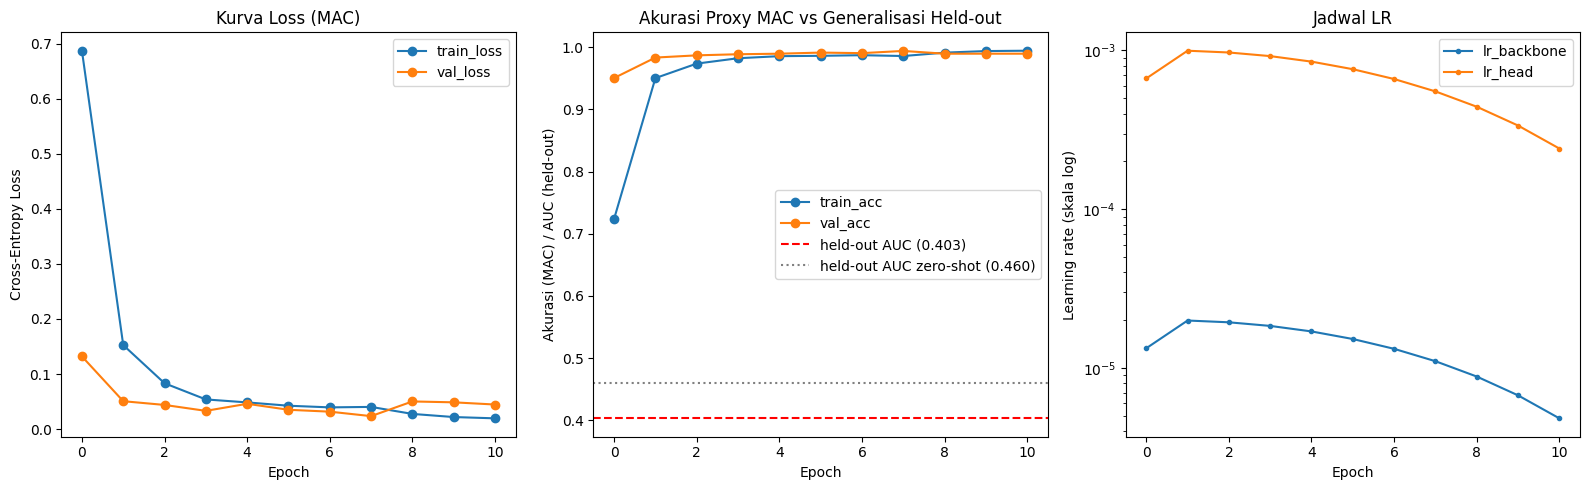

Plot tersimpan: training_curves_AOT.png


In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(history["train_loss"], marker="o", label="train_loss")
ax.plot(history["val_loss"], marker="o", label="val_loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Kurva Loss (MAC)")
ax.legend()

ax = axes[1]
ax.plot(history["train_acc"], marker="o", label="train_acc")
ax.plot(history["val_acc"], marker="o", label="val_acc")
ax.axhline(auc_embedding_finetuned, color="red", ls="--", label=f"held-out AUC ({auc_embedding_finetuned:.3f})")
ax.axhline(auc_embedding_original, color="gray", ls=":", label=f"held-out AUC zero-shot ({auc_embedding_original:.3f})")
ax.set_xlabel("Epoch"); ax.set_ylabel("Akurasi (MAC) / AUC (held-out)")
ax.set_title("Akurasi Proxy MAC vs Generalisasi Held-out")
ax.legend()

ax = axes[2]
ax.plot(history["lr_backbone"], marker=".", label="lr_backbone")
ax.plot(history["lr_head"], marker=".", label="lr_head")
ax.set_yscale("log")
ax.set_xlabel("Epoch"); ax.set_ylabel("Learning rate (skala log)")
ax.set_title("Jadwal LR")
ax.legend()

plt.tight_layout()
plt.savefig("training_curves_AOT.png", dpi=150)
plt.show()
print("Plot tersimpan: training_curves_AOT.png")


# Part IV: Inference Walkthrough


## 19. Block C: Instance-Specific Calibration


In [23]:
from dataclasses import dataclass as _dc


@_dc
class MachineBaseline:
    machine_label: str
    n_windows: int
    embeddings: np.ndarray
    backend_stats: Dict[str, Dict[str, float]]
    calibration_quality: str


def embed_windows(windows: List[np.ndarray]) -> np.ndarray:
    batch = torch.stack([torch.from_numpy(w.astype(np.float32)) for w in windows]).to(device)
    return model.embed(batch).cpu().numpy()


def build_baseline(embeddings: np.ndarray, machine_label: str, cfg: Config) -> MachineBaseline:
    n = embeddings.shape[0]
    quality = "baik" if n >= cfg.min_calibration_windows else "rendah"

    raw_by_backend: Dict[str, list] = {name: [] for name in ("cosine", "mahalanobis", "knn", "pca")}
    for i in range(n):
        bank_loo = np.delete(embeddings, i, axis=0)
        if len(bank_loo) < 2:
            continue
        raw = compute_all_backend_scores(embeddings[i], bank_loo, cfg)
        for name, val in raw.items():
            raw_by_backend[name].append(val)

    backend_stats: Dict[str, Dict[str, float]] = {}
    for name, scores in raw_by_backend.items():
        arr = np.array(scores) if scores else np.array([0.0])
        backend_stats[name] = {"mu": float(arr.mean()), "sigma": float(arr.std() + 1e-8)}

    return MachineBaseline(
        machine_label=machine_label, n_windows=n, embeddings=embeddings.astype(np.float32),
        backend_stats=backend_stats, calibration_quality=quality,
    )


print("Blok C (kalibrasi) siap. Catatan: compute_all_backend_scores didefinisikan di Bagian 21 -- "
      "jalankan Bagian 21 sebelum memanggil build_baseline().")

Blok C (kalibrasi) siap. Catatan: compute_all_backend_scores didefinisikan di Bagian 21 -- jalankan Bagian 21 sebelum memanggil build_baseline().


## 20. Block D: Multi-Backend Scoring & Fusion


In [24]:
def _cosine_score(query: np.ndarray, bank: np.ndarray) -> float:
    bank_norm = bank / (np.linalg.norm(bank, axis=1, keepdims=True) + 1e-12)
    q_norm = query / (np.linalg.norm(query) + 1e-12)
    sims = bank_norm @ q_norm
    return float(1.0 - sims.max())


def _mahalanobis_score(query: np.ndarray, bank: np.ndarray, shrinkage: float) -> float:
    mu = bank.mean(axis=0)
    cov = np.cov(bank, rowvar=False)
    d = cov.shape[0]
    cov_shrunk = (1 - shrinkage) * cov + shrinkage * (np.trace(cov) / d) * np.eye(d)
    try:
        inv = np.linalg.inv(cov_shrunk)
    except np.linalg.LinAlgError:
        inv = np.linalg.pinv(cov_shrunk)
    diff = query - mu
    return float(np.sqrt(max(diff @ inv @ diff.T, 0.0)))


def _knn_density_score(query: np.ndarray, bank: np.ndarray, k: int) -> float:
    dists = np.linalg.norm(bank - query, axis=1)
    k_eff = max(1, min(k, len(dists)))
    return float(np.sort(dists)[:k_eff].mean())


def _pca_residual_score(query: np.ndarray, bank: np.ndarray, variance_target: float) -> float:
    mu = bank.mean(axis=0)
    centered = bank - mu
    _, s, vt = np.linalg.svd(centered, full_matrices=False)
    total = np.sum(s ** 2)
    if total < 1e-12:
        return 0.0
    var_ratio = (s ** 2) / total
    cum = np.cumsum(var_ratio)
    n_components = min(max(1, int(np.searchsorted(cum, variance_target) + 1)), vt.shape[0])
    components = vt[:n_components]
    q_centered = query - mu
    proj = components.T @ (components @ q_centered)
    return float(np.linalg.norm(q_centered - proj))


def compute_all_backend_scores(query: np.ndarray, bank: np.ndarray, cfg: Config) -> Dict[str, float]:
    if len(bank) < 2:
        raise ValueError(f"Memory bank terlalu kecil ({len(bank)} embedding).")
    return {
        "cosine": _cosine_score(query, bank),
        "mahalanobis": _mahalanobis_score(query, bank, cfg.mahalanobis_shrinkage),
        "knn": _knn_density_score(query, bank, cfg.knn_k),
        "pca": _pca_residual_score(query, bank, cfg.pca_variance_target),
    }


def fuse_scores(raw_scores: Dict[str, float], backend_stats: Dict[str, Dict[str, float]]) -> float:
    z_scores = []
    for name, raw in raw_scores.items():
        stats = backend_stats[name]
        z_scores.append((raw - stats["mu"]) / stats["sigma"])
    return float(min(z_scores))


print("Blok D (scoring) siap.")

Blok D (scoring) siap.


## 21. Block E: Decision & Interpretation


In [25]:
from scipy import stats as scipy_stats

DISCLAIMER = "Alat bantu triase, bukan diagnosis mengikat -- tetap perlu inspeksi teknisi."


@_dc
class HealthCard:
    status: str
    z_score: float
    health_score: Optional[float]
    calibration_quality: str
    dominant_indicator: Optional[str]
    disclaimer: str


def _dsp_features(w: np.ndarray) -> np.ndarray:
    kurt = float(scipy_stats.kurtosis(w))
    crest = float(np.max(np.abs(w)) / (np.sqrt(np.mean(w ** 2)) + 1e-12))
    spec = np.abs(np.fft.rfft(w))
    freqs = np.fft.rfftfreq(len(w))
    centroid = float(np.sum(freqs * spec) / (np.sum(spec) + 1e-12))
    return np.array([kurt, crest, centroid])


def _dsp_attribution(window: np.ndarray, calibration_windows: List[np.ndarray]) -> str:
    names = ["kurtosis", "crest_factor", "spectral_centroid"]
    test_feat = _dsp_features(window)
    calib_feats = np.array([_dsp_features(w) for w in calibration_windows])
    mu = calib_feats.mean(axis=0)
    sigma = calib_feats.std(axis=0) + 1e-8
    z = np.abs((test_feat - mu) / sigma)
    return names[int(np.argmax(z))]


def compute_health_score(z: float, cfg: Config) -> Optional[float]:
    if not np.isfinite(z):
        return None
    score = 100.0 * (1.0 - z / cfg.z_critical)
    return float(max(0.0, min(100.0, score)))


def decide(
    window: np.ndarray,
    window_embedding: np.ndarray,
    baseline: MachineBaseline,
    cfg: Config,
    calibration_windows: Optional[List[np.ndarray]] = None,
) -> HealthCard:
    if baseline.calibration_quality == "rendah":
        return HealthCard("KALIBRASI_KURANG", float("nan"), None, baseline.calibration_quality, None, DISCLAIMER)

    raw_scores = compute_all_backend_scores(window_embedding, baseline.embeddings, cfg)
    z = fuse_scores(raw_scores, baseline.backend_stats)
    health_score = compute_health_score(z, cfg)

    if z >= cfg.z_critical:
        status = "CRITICAL"
    elif z >= cfg.z_warning:
        status = "WARNING"
    else:
        status = "NORMAL"

    dominant = None
    if status != "NORMAL" and calibration_windows:
        dominant = _dsp_attribution(window, calibration_windows)

    return HealthCard(status, z, health_score, baseline.calibration_quality, dominant, DISCLAIMER)


print("Blok E (keputusan) siap.")

Blok E (keputusan) siap.


## 23. Calibration, Inspection, Health Card


In [26]:
import random as _random
_rng_demo = _random.Random(CFG.seed)

demo_calib_paths = train_df[train_df.label == "normal"]["path"].tolist()[:20]
demo_test_normal = val_df[val_df.label == "normal"]["path"].tolist()
demo_test_abnormal = val_df[val_df.label == "abnormal"]["path"].tolist()

assert len(demo_calib_paths) >= 5, "Tidak cukup klip normal untuk demo kalibrasi."
assert demo_test_normal, "Tidak ada klip normal di val_df untuk demo."
assert demo_test_abnormal, "Tidak ada klip abnormal di val_df untuk demo."

demo_test_normal_path = demo_test_normal[0]
demo_test_abnormal_path = demo_test_abnormal[0]

print("=" * 70)
print("TAHAP 1: KALIBRASI")
print("=" * 70)
print(f"Memakai {len(demo_calib_paths)} klip normal sebagai sesi kalibrasi...")

calib_windows_demo: List[np.ndarray] = []
for p in demo_calib_paths:
    raw = load_audio(p, CFG)
    print(f"  {Path(p).name}: durasi mentah {len(raw)/CFG.sr:.1f}s", end="")
    xc = condition(raw, CFG.sr, CFG)
    windows = make_windows(xc, CFG.sr, CFG)
    print(f" -> {len(windows)} window setelah kondisi+windowing")
    calib_windows_demo.extend(windows)

print(f"\nTotal window kalibrasi: {len(calib_windows_demo)}")
calib_embeddings_demo = embed_windows(calib_windows_demo)
print(f"Embedding: shape {calib_embeddings_demo.shape}")

baseline_demo = build_baseline(calib_embeddings_demo, "Demo Machine", CFG)
print(f"MachineBaseline dibangun: n_windows={baseline_demo.n_windows}, "
      f"kualitas={baseline_demo.calibration_quality}")
print("Statistik backend (mu, sigma) hasil self-score leave-one-out:")
for name, stats in baseline_demo.backend_stats.items():
    print(f"  {name:12s}: mu={stats['mu']:.4f}  sigma={stats['sigma']:.4f}")

TAHAP 1: KALIBRASI
Memakai 20 klip normal sebagai sesi kalibrasi...
  00000680.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000081.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000900.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000761.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000961.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000044.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000054.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000239.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000633.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000629.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000634.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000120.wav: durasi mentah 10.0s -> 9 window setelah kondisi+windowing
  00000954.wav: durasi mentah 10.0s -> 9 win

In [27]:
def run_inspection_demo(audio_path: str, label_gt: str) -> None:
    print("=" * 70)
    print(f"TAHAP 2: INSPEKSI -- {Path(audio_path).name}  (ground truth: {label_gt})")
    print("=" * 70)
    raw = load_audio(audio_path, CFG)
    print(f"1. Audio dimuat: {len(raw)/CFG.sr:.1f} detik, {CFG.sr}Hz")

    xc = condition(raw, CFG.sr, CFG)
    print(f"2. Setelah condition() [bandpass+notch+normalize"
          f"{'+denoise' if CFG.enable_denoise else ''}]: peak={np.max(np.abs(xc)):.3f}")

    windows = make_windows(xc, CFG.sr, CFG)
    print(f"3. Setelah make_windows(): {len(windows)} window {CFG.window_sec}s (hop {CFG.hop_sec}s)")
    if not windows:
        print("   Tidak ada window valid -- quality gate menolak semua window. Berhenti.")
        return
    window = windows[0]

    embedding = embed_windows([window])[0]
    print(f"4. Setelah encoder.embed(): vektor dim={embedding.shape[0]}, "
          f"norm={np.linalg.norm(embedding):.3f} (harus ~1.0, L2-normalized)")

    raw_scores = compute_all_backend_scores(embedding, baseline_demo.embeddings, CFG)
    print("5. Skor mentah 4 backend terhadap memory bank kalibrasi:")
    for name, val in raw_scores.items():
        print(f"     {name:12s}: {val:.4f}")

    z = fuse_scores(raw_scores, baseline_demo.backend_stats)
    print(f"6. Setelah z-normalisasi + fusi MINIMUM: z = {z:.3f}  "
          f"(ambang WARNING={CFG.z_warning}, CRITICAL={CFG.z_critical})")

    card = decide(window, embedding, baseline_demo, CFG, calibration_windows=calib_windows_demo)
    hs_str = f"{card.health_score:.1f}" if card.health_score is not None else "N/A"
    print(f"\n>>> HASIL AKHIR: status={card.status}  z={card.z_score:.3f}  health_score={hs_str}  "
          f"indikator_dominan={card.dominant_indicator}")
    print(f">>> {card.disclaimer}")
    match = "COCOK" if (card.status == "NORMAL") == (label_gt == "normal") else "TIDAK COCOK"
    print(f">>> vs ground truth ({label_gt}): {match}")


run_inspection_demo(demo_test_normal_path, "normal")
print()
run_inspection_demo(demo_test_abnormal_path, "abnormal")

TAHAP 2: INSPEKSI -- 00000604.wav  (ground truth: normal)
1. Audio dimuat: 10.0 detik, 16000Hz
2. Setelah condition() [bandpass+notch+normalize]: peak=1.000
3. Setelah make_windows(): 9 window 2.0s (hop 1.0s)
4. Setelah encoder.embed(): vektor dim=768, norm=1.000 (harus ~1.0, L2-normalized)
5. Skor mentah 4 backend terhadap memory bank kalibrasi:
     cosine      : 0.0585
     mahalanobis : 25.6427
     knn         : 0.3769
     pca         : 0.3180
6. Setelah z-normalisasi + fusi MINIMUM: z = 1.494  (ambang WARNING=3.0, CRITICAL=6.0)

>>> HASIL AKHIR: status=NORMAL  z=1.494  health_score=75.1  indikator_dominan=None
>>> Alat bantu triase, bukan diagnosis mengikat -- tetap perlu inspeksi teknisi.
>>> vs ground truth (normal): COCOK

TAHAP 2: INSPEKSI -- 00000261.wav  (ground truth: abnormal)
1. Audio dimuat: 10.0 detik, 16000Hz
2. Setelah condition() [bandpass+notch+normalize]: peak=1.000
3. Setelah make_windows(): 9 window 2.0s (hop 1.0s)
4. Setelah encoder.embed(): vektor dim=768, no

# Part V: Evaluation 

## 24. Evaluation Configuration & Official Baseline Anchor


In [28]:
N_SEEDS_ABLATION = 3
MAX_TEST_CLIPS_PER_CLASS = 150

OFFICIAL_HITACHI_BASELINE_MINUS6DB = {
    "id_00": 0.5757, "id_02": 0.6401, "id_04": 0.5715,
}
anchor = sum(OFFICIAL_HITACHI_BASELINE_MINUS6DB.values()) / len(OFFICIAL_HITACHI_BASELINE_MINUS6DB)
print(f"Anchor baseline resmi (fan -6dB, rata-rata): {anchor:.4f}")
if DATASET_MODE != "mimii":
    print("PERHATIAN: DATASET_MODE bukan 'mimii' -- perbandingan ke baseline resmi Hitachi "
          "TIDAK APPLICABLE (baseline itu diukur khusus untuk unduhan Zenodo terverifikasi "
          "checksum; provenance dataset Anda saat ini tidak diverifikasi setara). "
          "Bagian ablasi di bawah tetap jalan untuk mengukur delta ANTAR TAHAP di data Anda "
          "sendiri (termasuk AUC di held-out unit kalau USES_HELDOUT_UNIT), tapi jangan "
          "bandingkan angkanya langsung ke tabel Hitachi.")

Anchor baseline resmi (fan -6dB, rata-rata): 0.5958
PERHATIAN: DATASET_MODE bukan 'mimii' -- perbandingan ke baseline resmi Hitachi TIDAK APPLICABLE (baseline itu diukur khusus untuk unduhan Zenodo terverifikasi checksum; provenance dataset Anda saat ini tidak diverifikasi setara). Bagian ablasi di bawah tetap jalan untuk mengukur delta ANTAR TAHAP di data Anda sendiri (termasuk AUC di held-out unit kalau USES_HELDOUT_UNIT), tapi jangan bandingkan angkanya langsung ke tabel Hitachi.


## 25. Core Evaluation Function 


In [29]:
def evaluate_machine(
    machine_id: str, manifest: pd.DataFrame, embed_fn: Callable[[List[np.ndarray]], np.ndarray],
    cfg: Config, n_calib: int, seed: int, max_test_per_class: int, backends: Optional[list] = None,
) -> float:
    rng = np.random.RandomState(seed)
    sub = manifest[manifest.model_id == machine_id]
    normal = sub[sub.label == "normal"]["path"].tolist()
    abnormal = sub[sub.label == "abnormal"]["path"].tolist()
    rng.shuffle(normal)
    rng.shuffle(abnormal)

    calib_paths = normal[:n_calib]
    test_paths = normal[n_calib:n_calib + max_test_per_class] + abnormal[:max_test_per_class]
    test_labels = [0] * len(normal[n_calib:n_calib + max_test_per_class]) + [1] * len(abnormal[:max_test_per_class])

    calib_windows = []
    for p in calib_paths:
        calib_windows.extend(make_windows(condition(load_audio(p, cfg), cfg.sr, cfg), cfg.sr, cfg))
    if len(calib_windows) < cfg.min_calibration_windows:
        raise ValueError(f"[{machine_id}] Cuma {len(calib_windows)} window kalibrasi.")
    baseline = build_baseline(embed_fn(calib_windows), machine_id, cfg)
    if backends is not None:
        stats_subset = {k: baseline.backend_stats[k] for k in backends}

    scores, labels = [], []
    for p, y in zip(test_paths, test_labels):
        windows = make_windows(condition(load_audio(p, cfg), cfg.sr, cfg), cfg.sr, cfg)
        if not windows:
            continue
        emb = embed_fn(windows)
        window_z = []
        for e in emb:
            raw = compute_all_backend_scores(e, baseline.embeddings, cfg)
            if backends is not None:
                raw = {k: v for k, v in raw.items() if k in backends}
                z = fuse_scores(raw, stats_subset)
            else:
                z = fuse_scores(raw, baseline.backend_stats)
            window_z.append(z)
        scores.append(float(np.mean(window_z)))
        labels.append(y)

    if len(set(labels)) < 2:
        return float("nan")
    return roc_auc_score(labels, scores)


def evaluate_stage(
    stage_name: str, manifest: pd.DataFrame, machine_ids: list,
    embed_fn: Callable[[List[np.ndarray]], np.ndarray], cfg: Config, backends: Optional[list] = None,
) -> pd.DataFrame:
    rows = []
    for mid in machine_ids:
        aucs = []
        for seed in range(N_SEEDS_ABLATION):
            auc = evaluate_machine(mid, manifest, embed_fn, cfg, 25, seed, MAX_TEST_CLIPS_PER_CLASS, backends)
            aucs.append(auc)
            print(f"  [{stage_name}] {mid} seed={seed}: AUC={auc:.4f}")
        rows.append({"stage": stage_name, "machine_id": mid,
                      "auc_mean": float(np.nanmean(aucs)), "auc_std": float(np.nanstd(aucs))})
    return pd.DataFrame(rows)


print("Fungsi evaluasi siap.")

Fungsi evaluasi siap.


## 26. B0: Zero-Shot BEATs + Cosine NN


In [30]:
def embed_fn_zeroshot(windows: List[np.ndarray]) -> np.ndarray:
    batch = torch.stack([torch.from_numpy(w.astype(np.float32)) for w in windows]).to(device)
    return embed_orig(batch).cpu().numpy()


ALL_MACHINE_IDS = sorted(MF.model_id.unique())
print(f"Evaluasi B0 pada machine IDs: {ALL_MACHINE_IDS}")

results_b0 = evaluate_stage("B0_zeroshot_cosine", MF, ALL_MACHINE_IDS, embed_fn_zeroshot, CFG, backends=["cosine"])
print(results_b0)
b0_mean = results_b0["auc_mean"].mean()
print(f"\nRata-rata AUC B0: {b0_mean:.4f}")

Evaluasi B0 pada machine IDs: ['id_00', 'id_02', 'id_04', 'id_06']
  [B0_zeroshot_cosine] id_00 seed=0: AUC=0.5779
  [B0_zeroshot_cosine] id_00 seed=1: AUC=0.5609
  [B0_zeroshot_cosine] id_00 seed=2: AUC=0.5379
  [B0_zeroshot_cosine] id_02 seed=0: AUC=0.5797
  [B0_zeroshot_cosine] id_02 seed=1: AUC=0.6162
  [B0_zeroshot_cosine] id_02 seed=2: AUC=0.5471
  [B0_zeroshot_cosine] id_04 seed=0: AUC=0.5000
  [B0_zeroshot_cosine] id_04 seed=1: AUC=0.5382
  [B0_zeroshot_cosine] id_04 seed=2: AUC=0.5282
  [B0_zeroshot_cosine] id_06 seed=0: AUC=0.6976
  [B0_zeroshot_cosine] id_06 seed=1: AUC=0.6922
  [B0_zeroshot_cosine] id_06 seed=2: AUC=0.7355
                stage machine_id  auc_mean   auc_std
0  B0_zeroshot_cosine      id_00  0.558889  0.016373
1  B0_zeroshot_cosine      id_02  0.581022  0.028229
2  B0_zeroshot_cosine      id_04  0.522133  0.016179
3  B0_zeroshot_cosine      id_06  0.708444  0.019235

Rata-rata AUC B0: 0.5926


## 27. B1: Zero-Shot BEATs + Multi-Backend Fusion


In [31]:
results_b1 = evaluate_stage("B1_zeroshot_fusion", MF, ALL_MACHINE_IDS, embed_fn_zeroshot, CFG, backends=None)
print(results_b1)
b1_mean = results_b1["auc_mean"].mean()
print(f"\nRata-rata AUC B1: {b1_mean:.4f}  (delta vs B0: {b1_mean - b0_mean:+.4f})")

  [B1_zeroshot_fusion] id_00 seed=0: AUC=0.5790
  [B1_zeroshot_fusion] id_00 seed=1: AUC=0.5584
  [B1_zeroshot_fusion] id_00 seed=2: AUC=0.5404
  [B1_zeroshot_fusion] id_02 seed=0: AUC=0.5923
  [B1_zeroshot_fusion] id_02 seed=1: AUC=0.6260
  [B1_zeroshot_fusion] id_02 seed=2: AUC=0.5539
  [B1_zeroshot_fusion] id_04 seed=0: AUC=0.5100
  [B1_zeroshot_fusion] id_04 seed=1: AUC=0.5394
  [B1_zeroshot_fusion] id_04 seed=2: AUC=0.5265
  [B1_zeroshot_fusion] id_06 seed=0: AUC=0.7069
  [B1_zeroshot_fusion] id_06 seed=1: AUC=0.7117
  [B1_zeroshot_fusion] id_06 seed=2: AUC=0.7493
                stage machine_id  auc_mean   auc_std
0  B1_zeroshot_fusion      id_00  0.559259  0.015761
1  B1_zeroshot_fusion      id_02  0.590726  0.029487
2  B1_zeroshot_fusion      id_04  0.525304  0.012041
3  B1_zeroshot_fusion      id_06  0.722637  0.018949

Rata-rata AUC B1: 0.5995  (delta vs B0: +0.0069)


## 28. B2: Backbone Fine-Tuned + Multi-Backend


In [33]:
def embed_fn_finetuned(windows: List[np.ndarray]) -> np.ndarray:
    return embed_windows(windows)


results_b2 = evaluate_stage("B2_finetuned_fusion", MF, ALL_MACHINE_IDS, embed_fn_finetuned, CFG, backends=None)
print(results_b2)
b2_mean = results_b2["auc_mean"].mean()
print(f"\nRata-rata AUC B2: {b2_mean:.4f}  (delta vs B1: {b2_mean - b1_mean:+.4f})")

if USES_HELDOUT_UNIT:
    b2_holdout = results_b2[results_b2.machine_id == CFG.holdout_machine_id]
    b1_holdout = results_b1[results_b1.machine_id == CFG.holdout_machine_id]
    if len(b2_holdout) and len(b1_holdout):
        d = float(b2_holdout.auc_mean.iloc[0] - b1_holdout.auc_mean.iloc[0])
        print(f"AUC B2 di held-out unit ({CFG.holdout_machine_id}): "
              f"{float(b2_holdout.auc_mean.iloc[0]):.4f} (delta vs B1: {d:+.4f})")
        if d <= 0:
            print("CATATAN: fine-tuning TIDAK terbukti membantu di unit held-out -- laporkan apa adanya.")

  [B2_finetuned_fusion] id_00 seed=0: AUC=0.6035
  [B2_finetuned_fusion] id_00 seed=1: AUC=0.6035
  [B2_finetuned_fusion] id_00 seed=2: AUC=0.5658
  [B2_finetuned_fusion] id_02 seed=0: AUC=0.7241
  [B2_finetuned_fusion] id_02 seed=1: AUC=0.7439
  [B2_finetuned_fusion] id_02 seed=2: AUC=0.7196
  [B2_finetuned_fusion] id_04 seed=0: AUC=0.5213
  [B2_finetuned_fusion] id_04 seed=1: AUC=0.5779
  [B2_finetuned_fusion] id_04 seed=2: AUC=0.5535
  [B2_finetuned_fusion] id_06 seed=0: AUC=0.8119
  [B2_finetuned_fusion] id_06 seed=1: AUC=0.8338
  [B2_finetuned_fusion] id_06 seed=2: AUC=0.8422
                 stage machine_id  auc_mean   auc_std
0  B2_finetuned_fusion      id_00  0.590919  0.017777
1  B2_finetuned_fusion      id_02  0.729215  0.010555
2  B2_finetuned_fusion      id_04  0.550919  0.023170
3  B2_finetuned_fusion      id_06  0.829304  0.012763

Rata-rata AUC B2: 0.6751  (delta vs B1: +0.0756)
AUC B2 di held-out unit (id_04): 0.5509 (delta vs B1: +0.0256)


## 29. HPSS Denoise Ablation


In [34]:
denoise_target_id = CFG.holdout_machine_id if USES_HELDOUT_UNIT else ALL_MACHINE_IDS[0]
cfg_denoise_on = replace(CFG, enable_denoise=True)

auc_denoise_off = evaluate_machine(denoise_target_id, MF, embed_fn_finetuned, CFG, 25, 0, MAX_TEST_CLIPS_PER_CLASS)
auc_denoise_on = evaluate_machine(denoise_target_id, MF, embed_fn_finetuned, cfg_denoise_on, 25, 0, MAX_TEST_CLIPS_PER_CLASS)

print(f"AUC denoise OFF: {auc_denoise_off:.4f}")
print(f"AUC denoise ON : {auc_denoise_on:.4f}")
print(f"Delta: {auc_denoise_on - auc_denoise_off:+.4f}")
if auc_denoise_on <= auc_denoise_off:
    print("Denoise TIDAK terbukti membantu -- biarkan enable_denoise=False di ai/config.py.")
else:
    print("Denoise terbukti membantu -- pertimbangkan mengubah default, sebutkan angka ini di proposal.")

AUC denoise OFF: 0.5213
AUC denoise ON : 0.5844
Delta: +0.0631
Denoise terbukti membantu -- pertimbangkan mengubah default, sebutkan angka ini di proposal.


## 30. Results Summary


In [35]:
all_results = pd.concat([results_b0, results_b1, results_b2], ignore_index=True)
pivot = all_results.pivot(index="machine_id", columns="stage", values="auc_mean")

if DATASET_MODE == "mimii":
    baseline_series = pd.Series(OFFICIAL_HITACHI_BASELINE_MINUS6DB, name="baseline_resmi_hitachi")
    pivot = pivot.join(baseline_series, how="left")

print(pivot.round(4))
print(f"\nRata-rata per stage:\n{pivot.mean(numeric_only=True).round(4)}")

all_results.to_csv("ablation_results_AOT.csv", index=False)
print("\nHasil mentah tersimpan: ablation_results_AOT.csv")

stage       B0_zeroshot_cosine  B1_zeroshot_fusion  B2_finetuned_fusion
machine_id                                                             
id_00                   0.5589              0.5593               0.5909
id_02                   0.5810              0.5907               0.7292
id_04                   0.5221              0.5253               0.5509
id_06                   0.7084              0.7226               0.8293

Rata-rata per stage:
stage
B0_zeroshot_cosine     0.5926
B1_zeroshot_fusion     0.5995
B2_finetuned_fusion    0.6751
dtype: float64

Hasil mentah tersimpan: ablation_results_AOT.csv


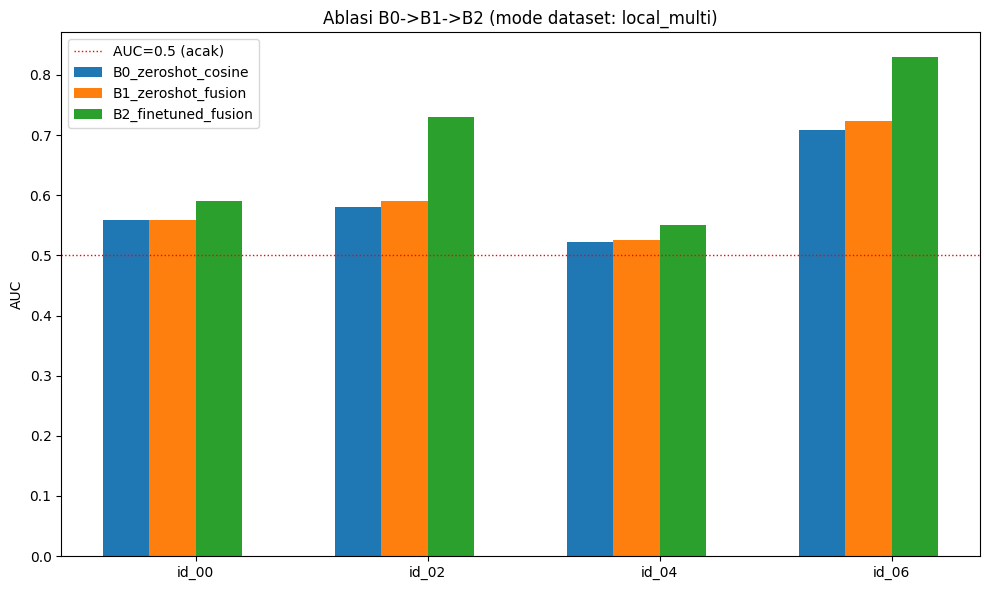

Plot tersimpan: ablation_results_AOT.png


In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
stages_present = [s for s in ["B0_zeroshot_cosine", "B1_zeroshot_fusion", "B2_finetuned_fusion"] if s in pivot.columns]
x = np.arange(len(pivot.index))
width = 0.8 / (len(stages_present) + 1)

for i, stage in enumerate(stages_present):
    ax.bar(x + i * width, pivot[stage], width, label=stage)
if "baseline_resmi_hitachi" in pivot.columns:
    ax.bar(x + len(stages_present) * width, pivot["baseline_resmi_hitachi"], width,
           label="Baseline resmi Hitachi (DAE)", color="gray")

ax.set_xticks(x + width * len(stages_present) / 2)
ax.set_xticklabels(pivot.index)
ax.set_ylabel("AUC")
ax.set_title(f"Ablasi B0->B1->B2 (mode dataset: {DATASET_MODE})")
ax.axhline(0.5, color="red", linestyle=":", linewidth=1, label="AUC=0.5 (acak)")
ax.legend()
plt.tight_layout()
plt.savefig("ablation_results_AOT.png", dpi=150)
plt.show()
print("Plot tersimpan: ablation_results_AOT.png")

In [37]:
with open("results.md", "w") as f:
    f.write("# Hasil Ablasi B0 -> B1 -> B2 -- AUDIAX\n\n")
    f.write(f"dataset_mode={DATASET_MODE}, N_SEEDS={N_SEEDS_ABLATION}, "
            f"MAX_TEST_CLIPS_PER_CLASS={MAX_TEST_CLIPS_PER_CLASS}\n\n")
    f.write(pivot.round(4).to_markdown())
    f.write("\n\nRata-rata per stage:\n\n")
    f.write(pivot.mean(numeric_only=True).round(4).to_markdown())
    f.write(f"\n\nAblasi denoise ({denoise_target_id}): OFF={auc_denoise_off:.4f}, "
            f"ON={auc_denoise_on:.4f}, delta={auc_denoise_on - auc_denoise_off:+.4f}\n")

print("Tersimpan: results.md")  

Tersimpan: results.md
